In [ ]:
# WIP integracion

## Pruebas con oversampling (GBM)

In [89]:
# ======================================================================
# NUEVO: Grid Search GBM con SMOTE (Imbalanced-Learn) - SIN VARIABLES CONTINUAS
# ======================================================================
import warnings
import pandas as pd
import numpy as np

# IMPORTANTE: Usamos el Pipeline de imblearn
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE  # Usamos SMOTE estándar, ya que todo es 0 y 1

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV

# Mantenemos fielmente tus cortes seleccionados
pipe_prep = Pipeline([
    ("binar", MultiThresholdBinarizer(cuts_map=cuts_seleccionados_gbm)),
    ("prep", preprocesador_base_dinamico(escalar_numericas=False))
])

# Ajustamos la preparación inicial
X_train_trans = pipe_prep.fit_transform(X_train)

# El Pipeline ahora inyecta datos sintéticos SOLAMENTE durante el train
pipe_gbm_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42, sampling_strategy='auto')),
    ("clf", GradientBoostingClassifier(random_state=42))
])

param_grid_gbm_smote = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__max_depth": [3, 5],
    "clf__subsample": [0.8, 1.0],
}

grid_gbm_smote = GridSearchCV(
    estimator=pipe_gbm_smote,
    param_grid=param_grid_gbm_smote,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc", 
    n_jobs=-1,
    verbose=1
)

print(f"Ejecutando GridSearchCV sobre GBM + SMOTE (Solo Binarizadas)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    # Entrenamos sobre los datos preparados
    grid_gbm_smote.fit(X_train_trans, y_train)

print(f"\nMejor ROC-AUC (CV): {grid_gbm_smote.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_gbm_smote.best_params_}")

Ejecutando GridSearchCV sobre GBM + SMOTE (Solo Binarizadas)...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Mejor ROC-AUC (CV): 0.7258
Mejores hiperparámetros: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 200, 'clf__subsample': 1.0}


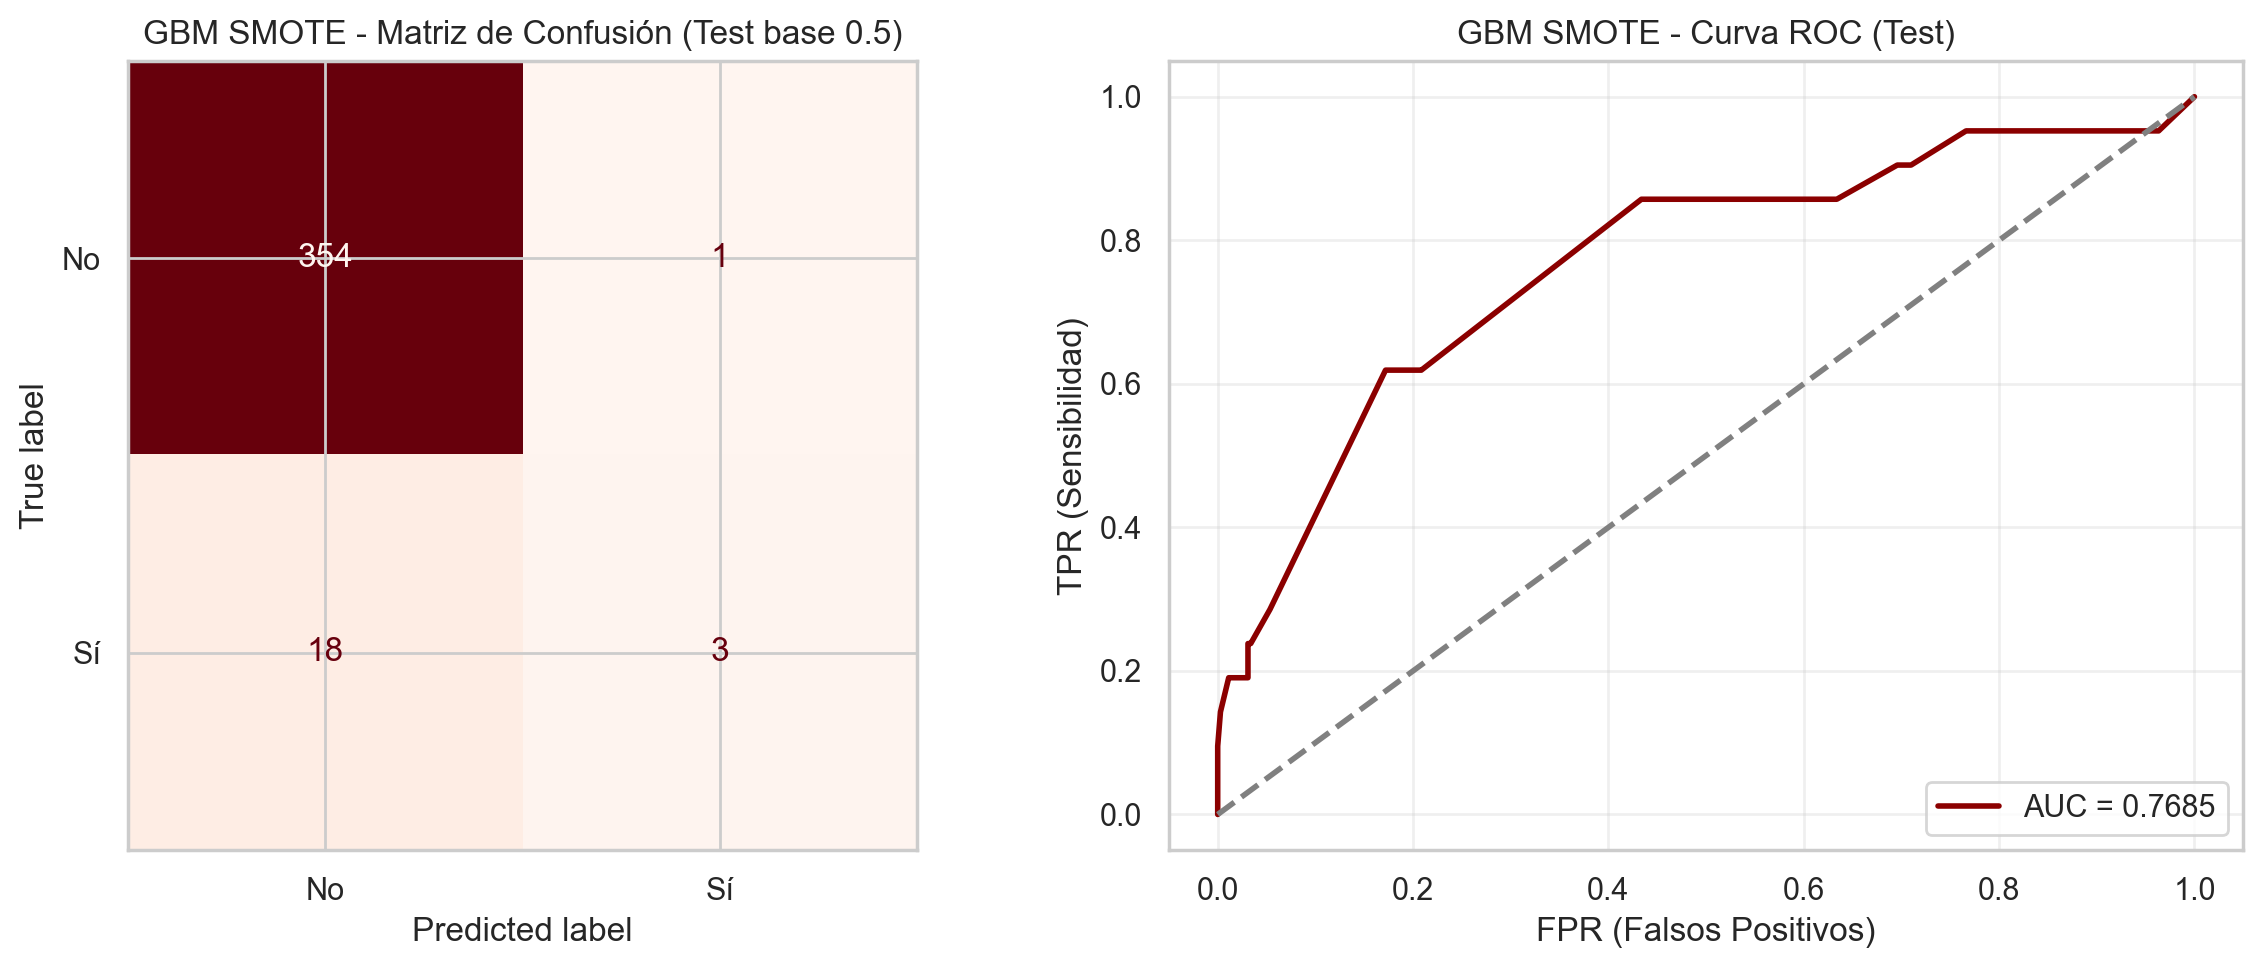


RESULTADOS TEST FINAL - GBM con OVERSAMPLING & CALIBRACIÓN
ROC-AUC:  0.7685
PR-AUC:   0.2739
F1-Score: 0.2400


In [90]:
# ======================================================================
# Test Final con calibrador sobre el modelo OVERSAMPLED
# ======================================================================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.calibration import CalibratedClassifierCV

# 1. Recuperar el pipeline general + SMOTE
best_model_gbm_smote = grid_gbm_smote.best_estimator_

# 2. Calibración! (Obligatorio para que los scores SMOTE vuelvan al "mundo real")
calibrated_gbm_smote = CalibratedClassifierCV(estimator=best_model_gbm_smote, method='isotonic', cv=5)
calibrated_gbm_smote.fit(X_train_trans, y_train)

# 3. Predicciones en TEST
X_test_trans = pipe_prep.transform(X_test)

y_pred_test_gbm_smote = calibrated_gbm_smote.predict(X_test_trans)
y_proba_test_gbm_smote = calibrated_gbm_smote.predict_proba(X_test_trans)[:, 1]

auc_test_gbm_s = roc_auc_score(y_test, y_proba_test_gbm_smote)
pr_auc_test_gbm_s = average_precision_score(y_test, y_proba_test_gbm_smote)
f1_test_gbm_s = f1_score(y_test, y_pred_test_gbm_smote)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_test_gbm_s = confusion_matrix(y_test, y_pred_test_gbm_smote)
disp_test_gbm_s = ConfusionMatrixDisplay(confusion_matrix=cm_test_gbm_s, display_labels=["No", "Sí"])
disp_test_gbm_s.plot(ax=axes[0], cmap="Reds", colorbar=False, values_format="d")
axes[0].set_title("GBM SMOTE - Matriz de Confusión (Test base 0.5)")

fpr_t_gbm_s, tpr_t_gbm_s, _ = roc_curve(y_test, y_proba_test_gbm_smote)
axes[1].plot(fpr_t_gbm_s, tpr_t_gbm_s, label=f"AUC = {auc_test_gbm_s:.4f}", color="darkred", lw=2)
axes[1].plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
axes[1].set_xlabel("FPR (Falsos Positivos)")
axes[1].set_ylabel("TPR (Sensibilidad)")
axes[1].set_title("GBM SMOTE - Curva ROC (Test)")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("RESULTADOS TEST FINAL - GBM con OVERSAMPLING & CALIBRACIÓN")
print("=" * 70)
print(f"ROC-AUC:  {auc_test_gbm_s:.4f}")
print(f"PR-AUC:   {pr_auc_test_gbm_s:.4f}")
print(f"F1-Score: {f1_test_gbm_s:.4f}")
print("=" * 70)

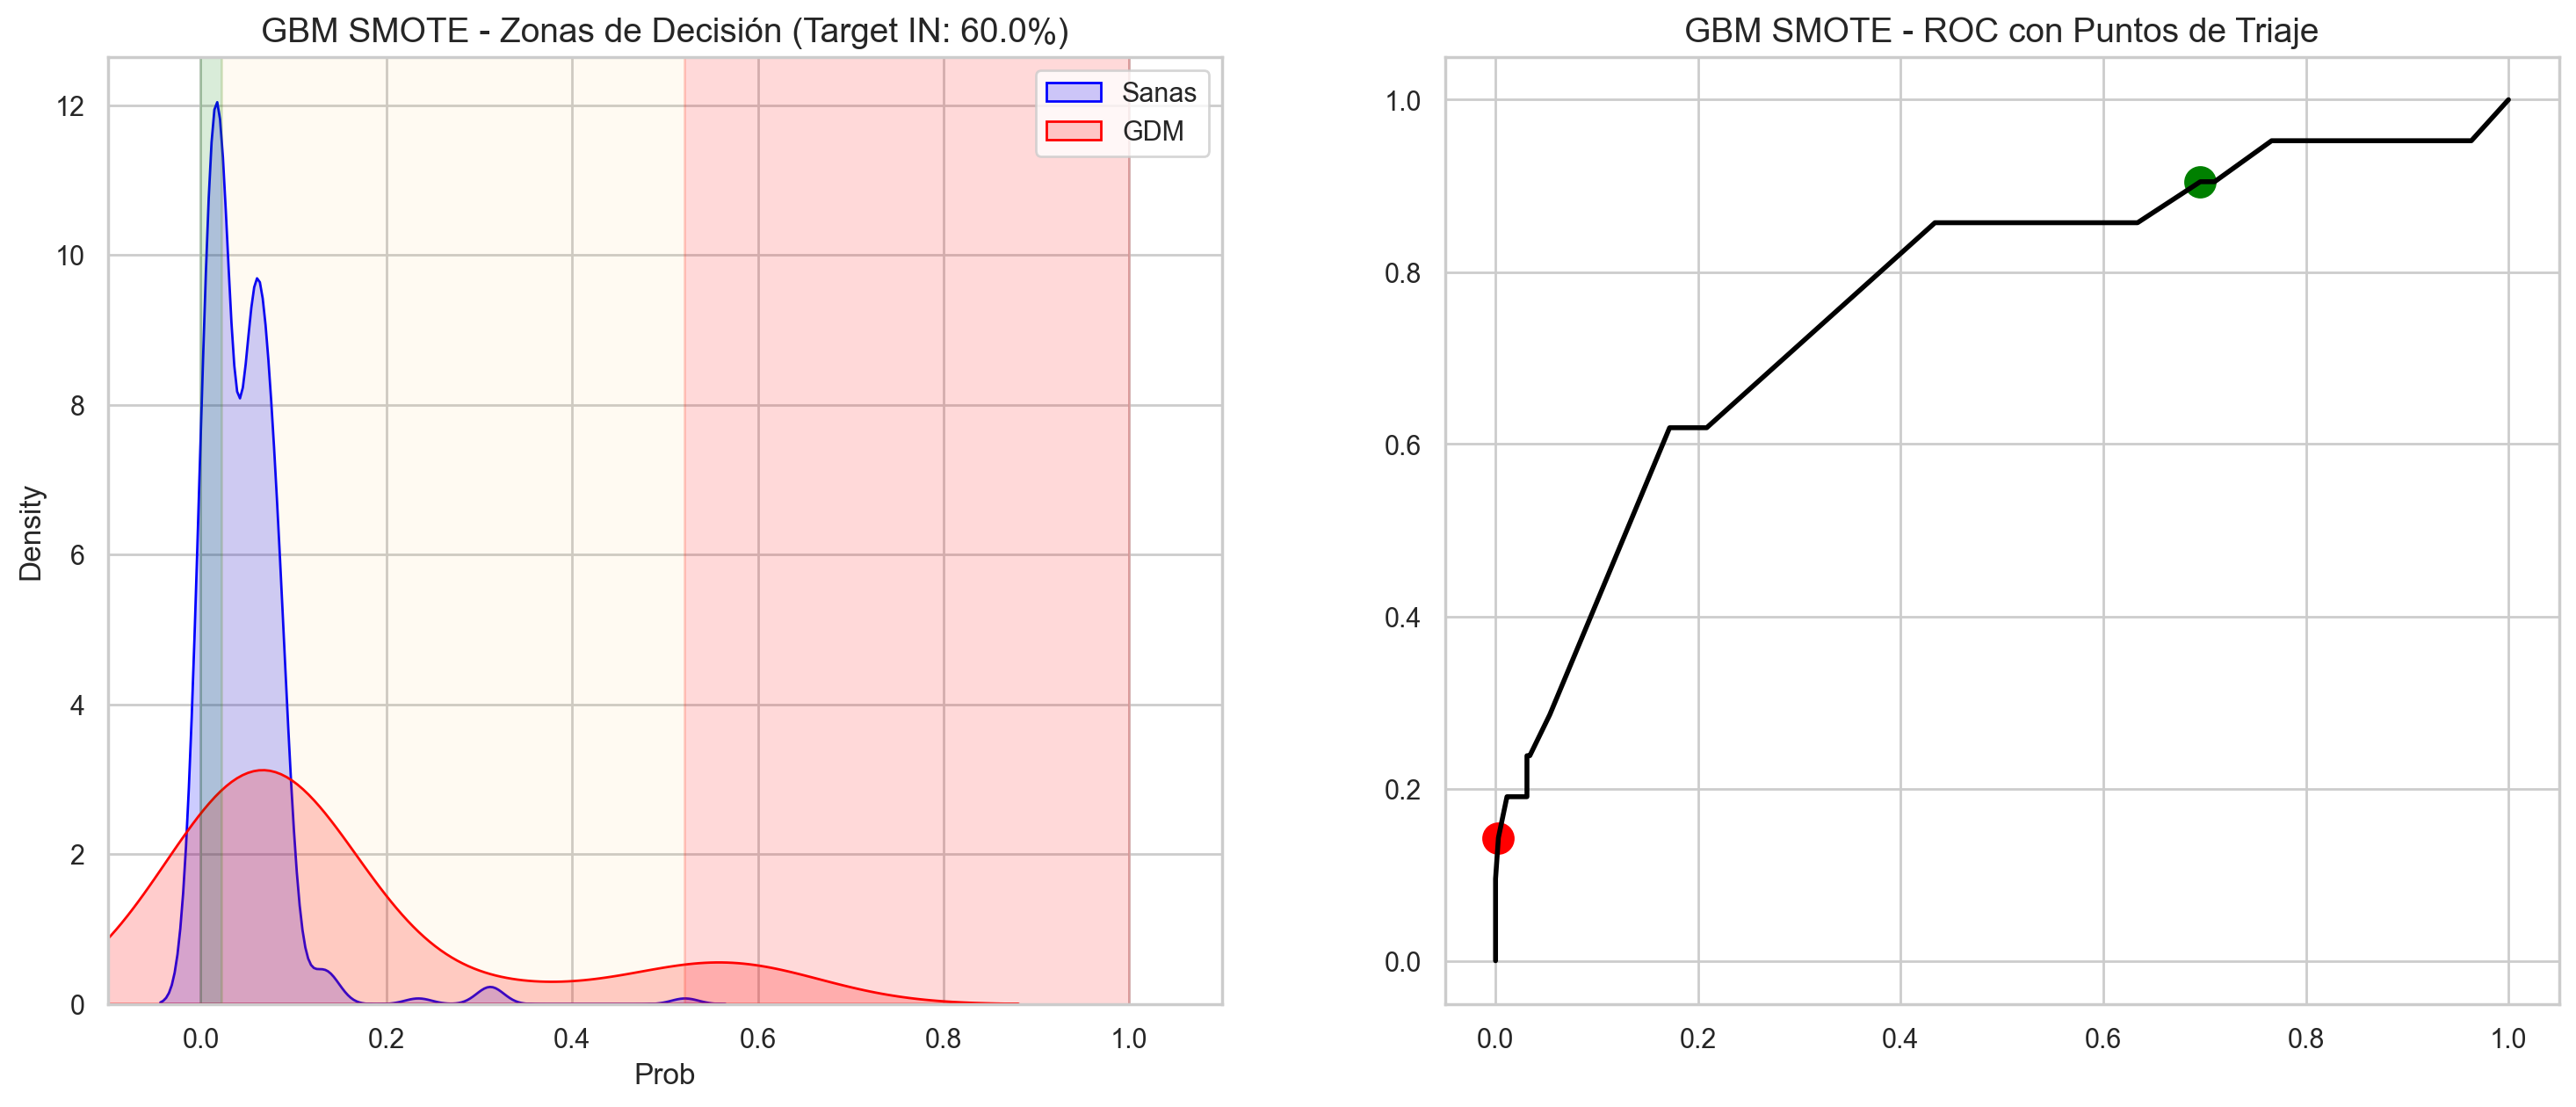


ANÁLISIS IMPACTO CLÍNICO - GBM SMOTE (Precisión Deseada: 60.0%)
Población total Test: 376 | Positivos Reales (GDM1=1): 21 (5.6%)
-------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL      | GDM1(+)    | % CLASE    | DESCRIPCIÓN
-------------------------------------------------------------------------------------
RULE-OUT (Descarte)       |  110 (29.3%) |    2 pts. |   1.8% | Falla en 2 pacientes (90.5% Sens)
ZONA GRIS (Sobrecarga)    |  262 (69.7%) |   16 pts. |   6.1% | Contiene al 76.2% de todas las enfermas
RULE-IN (Confirmación)    |    4 ( 1.1%) |    3 pts. |  75.0% | Precisión del 75.0% en esta zona
-------------------------------------------------------------------------------------
VALOR DEL MODELO (GBM SMOTE): Se evita sobrecarga al 30.3% de pacientes.


In [91]:
# ======================================================================
# Triaje Clínico - Evaluación Real (GBM + SMOTE)
# ======================================================================
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve

fpr_gbm_sm, tpr_gbm_sm, thresholds_roc_gbm_sm = roc_curve(y_test, y_proba_test_gbm_smote)
precision_gbm_sm, recall_gbm_sm, thresholds_pr_gbm_sm = precision_recall_curve(y_test, y_proba_test_gbm_smote)

# --- UMBRALES ---
target_sens = 0.90
idx_out = np.where(tpr_gbm_sm >= target_sens)[0][0]
thr_out_gbm_sm = thresholds_roc_gbm_sm[idx_out]

# RELAJAMOS LA PRECISIÓN AL 50% O 60% para capturar más positivos que necesitan SOG o seguimiento
target_prec = 0.60 
idx_in_list = np.where(precision_gbm_sm >= target_prec)[0]
if len(idx_in_list) > 0:
    idx_in = idx_in_list[0]
    thr_in_gbm_sm = thresholds_pr_gbm_sm[idx_in]
else:
    # Fallback si no llega al 60%
    thr_in_gbm_sm = np.percentile(y_proba_test_gbm_smote, 90)

# Categorización
def triage_gbm_smote(p):
    if p < thr_out_gbm_sm: return "RULE-OUT (Descarte)"
    elif p >= thr_in_gbm_sm: return "RULE-IN (Confirmación)"
    else: return "ZONA GRIS (Sobrecarga)"

df_triage_gbm_sm = pd.DataFrame({
    "Prob": y_proba_test_gbm_smote,
    "Real": y_test,
    "Cat": [triage_gbm_smote(p) for p in y_proba_test_gbm_smote]
})

# GRÁFICA DE TRIAJE CLÍNICO (KDE)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
sns.kdeplot(data=df_triage_gbm_sm[df_triage_gbm_sm["Real"] == 0], x="Prob", fill=True, ax=ax1, label="Sanas", color="blue", alpha=0.2, cut=3)
sns.kdeplot(data=df_triage_gbm_sm[df_triage_gbm_sm["Real"] == 1], x="Prob", fill=True, ax=ax1, label="GDM", color="red", alpha=0.2, cut=3)
ax1.axvspan(0, thr_out_gbm_sm, color='green', alpha=0.15)
ax1.axvspan(thr_out_gbm_sm, thr_in_gbm_sm, color='orange', alpha=0.05)
ax1.axvspan(thr_in_gbm_sm, 1, color='red', alpha=0.15)
ax1.set_title(f"GBM SMOTE - Zonas de Decisión (Target IN: {target_prec*100}%)", fontsize=14)
ax1.set_xlim(-0.1, 1.1)
ax1.legend()

ax2.plot(fpr_gbm_sm, tpr_gbm_sm, color='black', lw=2)
ax2.scatter(fpr_gbm_sm[idx_out], tpr_gbm_sm[idx_out], color='green', s=150)
idx_roc_in = np.argmin(np.abs(thresholds_roc_gbm_sm - thr_in_gbm_sm))
ax2.scatter(fpr_gbm_sm[idx_roc_in], tpr_gbm_sm[idx_roc_in], color='red', s=150)
ax2.set_title("GBM SMOTE - ROC con Puntos de Triaje", fontsize=14)
plt.show()

# REPORTE NUMÉRICO
print("\n" + "="*85)
print(f"ANÁLISIS IMPACTO CLÍNICO - GBM SMOTE (Precisión Deseada: {target_prec*100}%)")
print("="*85)
total_test = len(y_test)
positivos_totales = int(y_test.sum())
print(f"Población total Test: {total_test} | Positivos Reales (GDM1=1): {positivos_totales} ({positivos_totales/total_test:.1%})")
print("-" * 85)
print(f"{'CATEGORÍA':25s} | {'TOTAL':10s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN'}")
print("-" * 85)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    sub = df_triage_gbm_sm[df_triage_gbm_sm["Cat"] == cat]
    count = len(sub)
    positives = sub["Real"].sum()
    perc_total = (count / total_test) * 100 if total_test > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        desc = f"Falla en {int(positives)} pacientes ({(1-positives/positivos_totales):.1%} Sens)"
    elif "IN" in cat:
        desc = f"Precisión del {perc_pos:.1f}% en esta zona"
    else:
        desc = f"Contiene al {(positives/positivos_totales):.1%} de todas las enfermas"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 85)
ahorro = ((total_test - len(df_triage_gbm_sm[df_triage_gbm_sm["Cat"] == "ZONA GRIS (Sobrecarga)"])) / total_test) * 100
print(f"VALOR DEL MODELO (GBM SMOTE): Se evita sobrecarga al {ahorro:.1f}% de pacientes.")
print("="*85)

## Prueba con modelos categóricos

### RL

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay
)

warnings.filterwarnings("ignore")

if "df_sin_analisis" not in globals():
    raise NameError("No existe `df_sin_analisis` en el kernel.")

df_base = df_sin_analisis.copy()

if "GDM1" not in df_base.columns:
    raise NameError("La columna objetivo `GDM1` no existe en `df_sin_analisis`.")

y = df_base["GDM1"].astype(int)
X = df_base.drop(columns=["GDM1"]).copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print("Shapes iniciales")
print("X_train_raw:", X_train_raw.shape)
print("X_test_raw :", X_test_raw.shape)
print("y_train    :", y_train.shape)
print("y_test     :", y_test.shape)

numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
bool_cols = X_train_raw.select_dtypes(include=["bool", "boolean"]).columns.tolist()
cat_cols = [c for c in X_train_raw.columns if c not in numeric_cols and c not in bool_cols]

print("\nColumnas numéricas:", numeric_cols)
print("Columnas booleanas:", bool_cols)
print("Columnas categóricas:", cat_cols)

def _build_qcut_edges(series, n_bins=4):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.nunique() <= 1:
        return None
    try:
        _, edges = pd.qcut(s, q=n_bins, retbins=True, duplicates="drop")
        edges = np.unique(edges)
        if len(edges) < 2:
            return None
        edges[0] = -np.inf
        edges[-1] = np.inf
        return edges
    except Exception:
        return None

def _bin_series(series, edges):
    vals = pd.to_numeric(series, errors="coerce")
    if edges is None:
        return pd.Series(["__const__"] * len(vals), index=series.index, dtype="object")
    b = pd.cut(vals, bins=edges, include_lowest=True)
    return b.astype("object").astype(str).replace("nan", "__missing__")

def build_categorical_dataset(df, cut_map):
    out = pd.DataFrame(index=df.index)
    for col in df.columns:
        if col in cut_map:
            out[col] = _bin_series(df[col], cut_map[col])
        elif col in bool_cols:
            out[col] = df[col].astype("object").where(df[col].notna(), "__missing__")
        else:
            out[col] = df[col].astype("object").where(df[col].notna(), "__missing__")
    return out

Shapes iniciales
X_train_raw: (1314, 11)
X_test_raw : (564, 11)
y_train    : (1314,)
y_test     : (564,)

Columnas numéricas: ['1T hemoglobina glicada', '1t glucosa', 'edad', 'bmi']
Columnas booleanas: ['diabetes franca 1T', 'etnia', 'obesidad', 'edad>=35', 'gluc 1t>100', 'hba1c 1t>5,7']
Columnas categóricas: ['factores riesgo']


In [101]:
import numpy as np
import pandas as pd

def _round_clinical(x):
    if pd.isna(x):
        return x
    x = float(x)
    ax = abs(x)
    if ax >= 200:
        base = 10
    elif ax >= 100:
        base = 5
    elif ax >= 10:
        base = 1
    elif ax >= 1:
        base = 0.5
    else:
        base = 0.01
    return float(round(x / base) * base)

def learn_3cat_cuts(X_train, X_test, numeric_cols=None, q1=33, q2=66):
    if numeric_cols is None:
        numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cut_map = {}
    for col in numeric_cols:
        vals = X_train[col].dropna().values
        if len(np.unique(vals)) < 3:
            # not enough variability -> skip or create tiny margins
            mn, mx = np.nanmin(vals), np.nanmax(vals)
            if np.isnan(mn) or np.isnan(mx):
                continue
            c1 = mn + (mx - mn) / 3
            c2 = mn + 2 * (mx - mn) / 3
        else:
            c1 = np.percentile(vals, q1)
            c2 = np.percentile(vals, q2)
        c1r = _round_clinical(c1)
        c2r = _round_clinical(c2)
        # Ensure strict ordering; if equal, expand a bit using nearest unique values
        if not np.isfinite(c1r) or not np.isfinite(c2r) or c1r >= c2r:
            uniq = np.unique(vals)
            if uniq.size >= 3:
                c1r = float(uniq[max(0, uniq.size//3 - 1)])
                c2r = float(uniq[min(uniq.size-1, 2*uniq.size//3)])
            else:
                # fallback tiny offsets
                mid = np.median(vals) if len(vals)>0 else 0.0
                c1r = _round_clinical(mid - 0.01)
                c2r = _round_clinical(mid + 0.01)
        cut_map[col] = [c1r, c2r]

    # Apply to train/test: create categorical cols with labels bajo/medio/alto
    X_train_cat = X_train.copy()
    X_test_cat = X_test.copy()
    for col, (c1, c2) in cut_map.items():
        bins = [-np.inf, c1, c2, np.inf]
        labels = ["bajo", "medio", "alto"]
        X_train_cat[col + "_3cat"] = pd.cut(X_train_cat[col], bins=bins, labels=labels, include_lowest=True)
        X_test_cat[col + "_3cat"] = pd.cut(X_test_cat[col], bins=bins, labels=labels, include_lowest=True)

    # Summary table
    summary_rows = []
    for col, (c1, c2) in cut_map.items():
        s = X_train_cat[col + "_3cat"].value_counts(dropna=False).reindex(["bajo","medio","alto"]).fillna(0).astype(int)
        summary_rows.append({
            "variable": col,
            "cut_1": c1,
            "cut_2": c2,
            "bajo": s["bajo"],
            "medio": s["medio"],
            "alto": s["alto"]
        })
    summary_df = pd.DataFrame(summary_rows).sort_values("variable").reset_index(drop=True)

    return cut_map, X_train_cat, X_test_cat, summary_df

# Uso (asume que existen `X_train_raw` y `X_test_raw` en el kernel):
cut_map, X_train_cat, X_test_cat, cortes_summary = learn_3cat_cuts(X_train_raw, X_test_raw)
print("Cortes aprendidos (train):")
display(cortes_summary)

Cortes aprendidos (train):


,variable,cut_1,cut_2,bajo,medio,alto
0,1T hemoglobina glicada,5.0,5.5,298,829,187
1,1t glucosa,74.0,81.0,452,466,396
2,bmi,23.0,29.0,386,467,461
3,edad,31.0,36.0,447,441,426


In [102]:
# GridSearchCV robusto para RL categorizada (param_grid incluido) + tabla de resultados
import warnings
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone

# -----------------------
# 1) Param grid (ajusta valores si quieres)
# -----------------------
param_grid_rl = [
    # bloque L2 (rápido, lbfgs)
    {
        "clf__penalty": ["l2"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        "clf__solver": ["lbfgs"],
        "clf__class_weight": [None, "balanced"]
    },
    # bloque L1 (requiere saga o liblinear; aqui probamos saga para escalabilidad en multiclass si hiciera falta)
    {
        "clf__penalty": ["l1"],
        "clf__C": [0.001, 0.01, 0.1, 1.0, 10.0],
        "clf__solver": ["saga"],
        "clf__class_weight": [None, "balanced"]
    },
    # bloque ElasticNet (saga) con distintos l1_ratio
    {
        "clf__penalty": ["elasticnet"],
        "clf__C": [0.01, 0.1, 1.0],
        "clf__l1_ratio": [0.2, 0.5, 0.8],
        "clf__solver": ["saga"],
        "clf__class_weight": [None, "balanced"]
    }
]

# -----------------------
# 2) Compruebas previas
# -----------------------
if "X_train_cat" not in globals() or "y_train" not in globals():
    raise NameError("Asegura que `X_train_cat` y `y_train` existen en el kernel antes de ejecutar esta celda.")

# Detecta columnas categóricas generadas por los cortes (_3cat)
cat_cols = [c for c in X_train_cat.columns if c.endswith("_3cat")]
num_cols = [c for c in X_train_cat.columns if c not in cat_cols]

# ColumnTransformer: OneHotEncoding para categóricas (estilo notebook), passthrough numéricas
ct = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), cat_cols)],
    remainder="passthrough",
) if cat_cols else "passthrough"

# Pipeline final con step 'clf' para mantener el prefijo 'clf__' en param_grid si es necesario
pipe_rl = Pipeline([("pre", ct), ("clf", LogisticRegression(max_iter=4000, random_state=42))])

# -----------------------
# 4) GridSearchCV (estilo notebook)
# -----------------------
grid_rl = GridSearchCV(
    estimator=pipe_rl,
    param_grid=param_grid_rl,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc",
    n_jobs=-1,
    verbose=1,
)

print("Ejecutando GridSearchCV sobre RL categorizada (pipeline robusto)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_rl.fit(X_train_cat, y_train)

# -----------------------
# 5) Tabla de resultados y resumen (coherente con resto del notebook)
# -----------------------
res = pd.DataFrame(grid_rl.cv_results_)
cols = [
    "params",
    "mean_test_roc_auc", "std_test_roc_auc",
    "mean_test_pr_auc",  "std_test_pr_auc",
    "mean_test_f1",      "std_test_f1",
    "rank_test_roc_auc", "mean_fit_time"
]
available = [c for c in cols if c in res.columns]
table = res[available].copy()

if "rank_test_roc_auc" in table.columns:
    table = table.sort_values("rank_test_roc_auc")
else:
    table = table.sort_values("mean_test_roc_auc", ascending=False)

num_cols = [c for c in table.columns if c.startswith("mean_") or c.startswith("std_") or c.endswith("_time")]
table[num_cols] = table[num_cols].round(4)

print("\nTop 10 candidatos (ordenados por ROC-AUC):")
display(table.head(10))

print("\nMejor ROC-AUC (CV):", f"{grid_rl.best_score_:.4f}")
print("Mejores hiperparámetros:")
display(pd.DataFrame([grid_rl.best_params_]))

# -----------------------
# 6) Guarda el estimador y clon del clasificador para uso posterior (estilo notebook)
# -----------------------
best_rl = grid_rl.best_estimator_
if hasattr(best_rl, "named_steps"):
    clf_base_rl = clone(best_rl.named_steps["clf"])
else:
    clf_base_rl = clone(best_rl)

Ejecutando GridSearchCV sobre RL categorizada (pipeline robusto)...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Top 10 candidatos (ordenados por ROC-AUC):


,params,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_f1,std_test_f1,rank_test_roc_auc,mean_fit_time
4,"{'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.7902,0.0718,0.3172,0.0685,0.1637,0.0849,1,0.0411
2,"{'clf__C': 0.01, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.7876,0.0772,0.3025,0.0685,0.1417,0.0848,2,0.0243
0,"{'clf__C': 0.001, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.7860,0.0842,0.2926,0.0696,0.0235,0.0471,3,0.0158
3,"{'clf__C': 0.01, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.7859,0.0719,0.3067,0.0688,0.2207,0.0389,4,0.0382
5,"{'clf__C': 0.1, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.7859,0.0605,0.3071,0.0753,0.2155,0.0359,5,0.0835
6,"{'clf__C': 1.0, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.7848,0.0570,0.3075,0.0627,0.2036,0.0741,6,0.1164
1,"{'clf__C': 0.001, 'clf__class_weight': 'balanced', 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}",0.7840,0.0773,0.2911,0.0683,0.2196,0.0473,7,0.0240
20,"{'clf__C': 10.0, 'clf__class_weight': None, 'clf__penalty': 'l1', 'clf__solver': 'saga'}",0.7806,0.0539,0.3316,0.0795,0.2310,0.0943,8,1.7257
34,"{'clf__C': 1.0, 'clf__class_weight': None, 'clf__l1_ratio': 0.2, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}",0.7804,0.0575,0.3289,0.0816,0.1900,0.0788,9,1.3461
35,"{'clf__C': 1.0, 'clf__class_weight': None, 'clf__l1_ratio': 0.5, 'clf__penalty': 'elasticnet', 'clf__solver': 'saga'}",0.7800,0.0580,0.3335,0.0836,0.1634,0.1099,10,1.2614



Mejor ROC-AUC (CV): 0.7902
Mejores hiperparámetros:


,clf__C,clf__class_weight,clf__penalty,clf__solver
0,0.1,None,l2,lbfgs



RESULTADOS EN TEST
ROC-AUC: 0.7360
PR-AUC : 0.3466
F1     : 0.2778


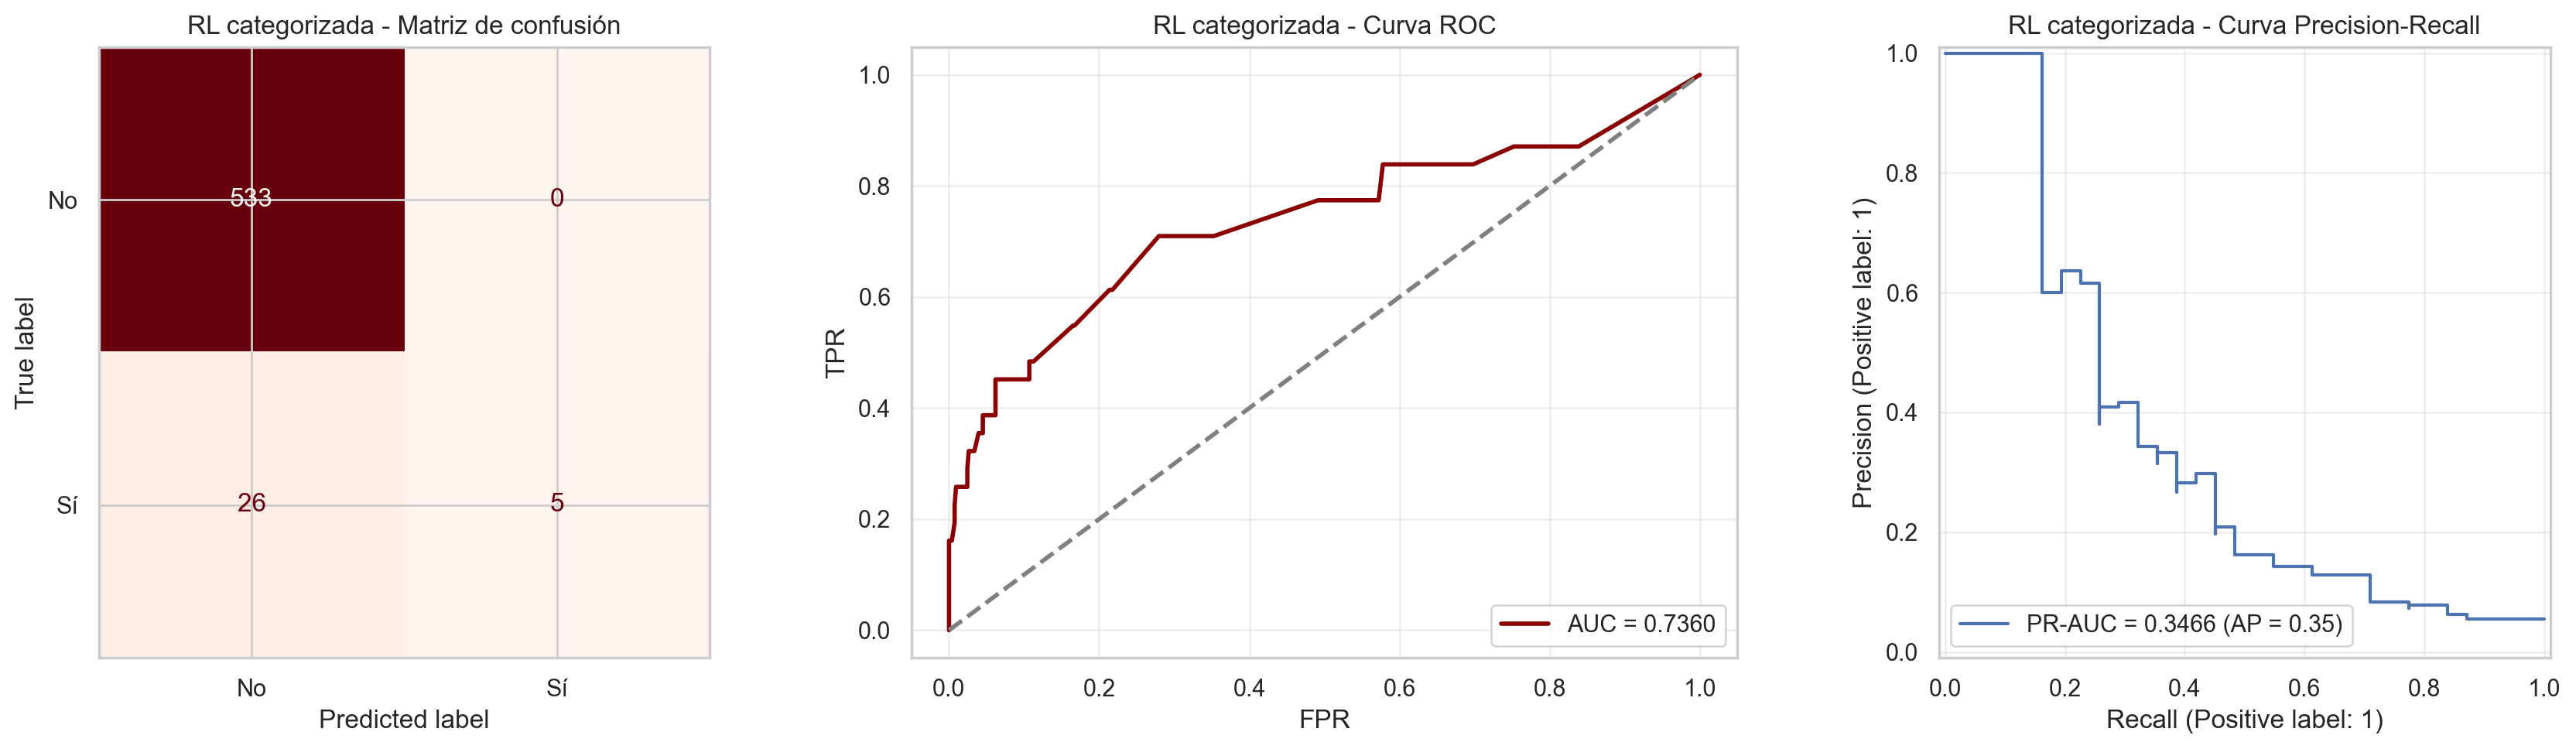

In [103]:
best_rl = grid_rl.best_estimator_

calibrated_rl = CalibratedClassifierCV(estimator=best_rl, method="isotonic", cv=3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    calibrated_rl.fit(X_train_cat, y_train)

y_pred_test = calibrated_rl.predict(X_test_cat)
y_proba_test = calibrated_rl.predict_proba(X_test_cat)[:, 1]

auc_test = roc_auc_score(y_test, y_proba_test)
pr_auc_test = average_precision_score(y_test, y_proba_test)
f1_test = f1_score(y_test, y_pred_test)

print("\n" + "=" * 85)
print("RESULTADOS EN TEST")
print("=" * 85)
print(f"ROC-AUC: {auc_test:.4f}")
print(f"PR-AUC : {pr_auc_test:.4f}")
print(f"F1     : {f1_test:.4f}")
print("=" * 85)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False, values_format="d")
axes[0].set_title("RL categorizada - Matriz de confusión")

fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test)
axes[1].plot(fpr_test, tpr_test, color="darkred", lw=2, label=f"AUC = {auc_test:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("RL categorizada - Curva ROC")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_test, y_proba_test, ax=axes[2], name=f"PR-AUC = {pr_auc_test:.4f}")
axes[2].set_title("RL categorizada - Curva Precision-Recall")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

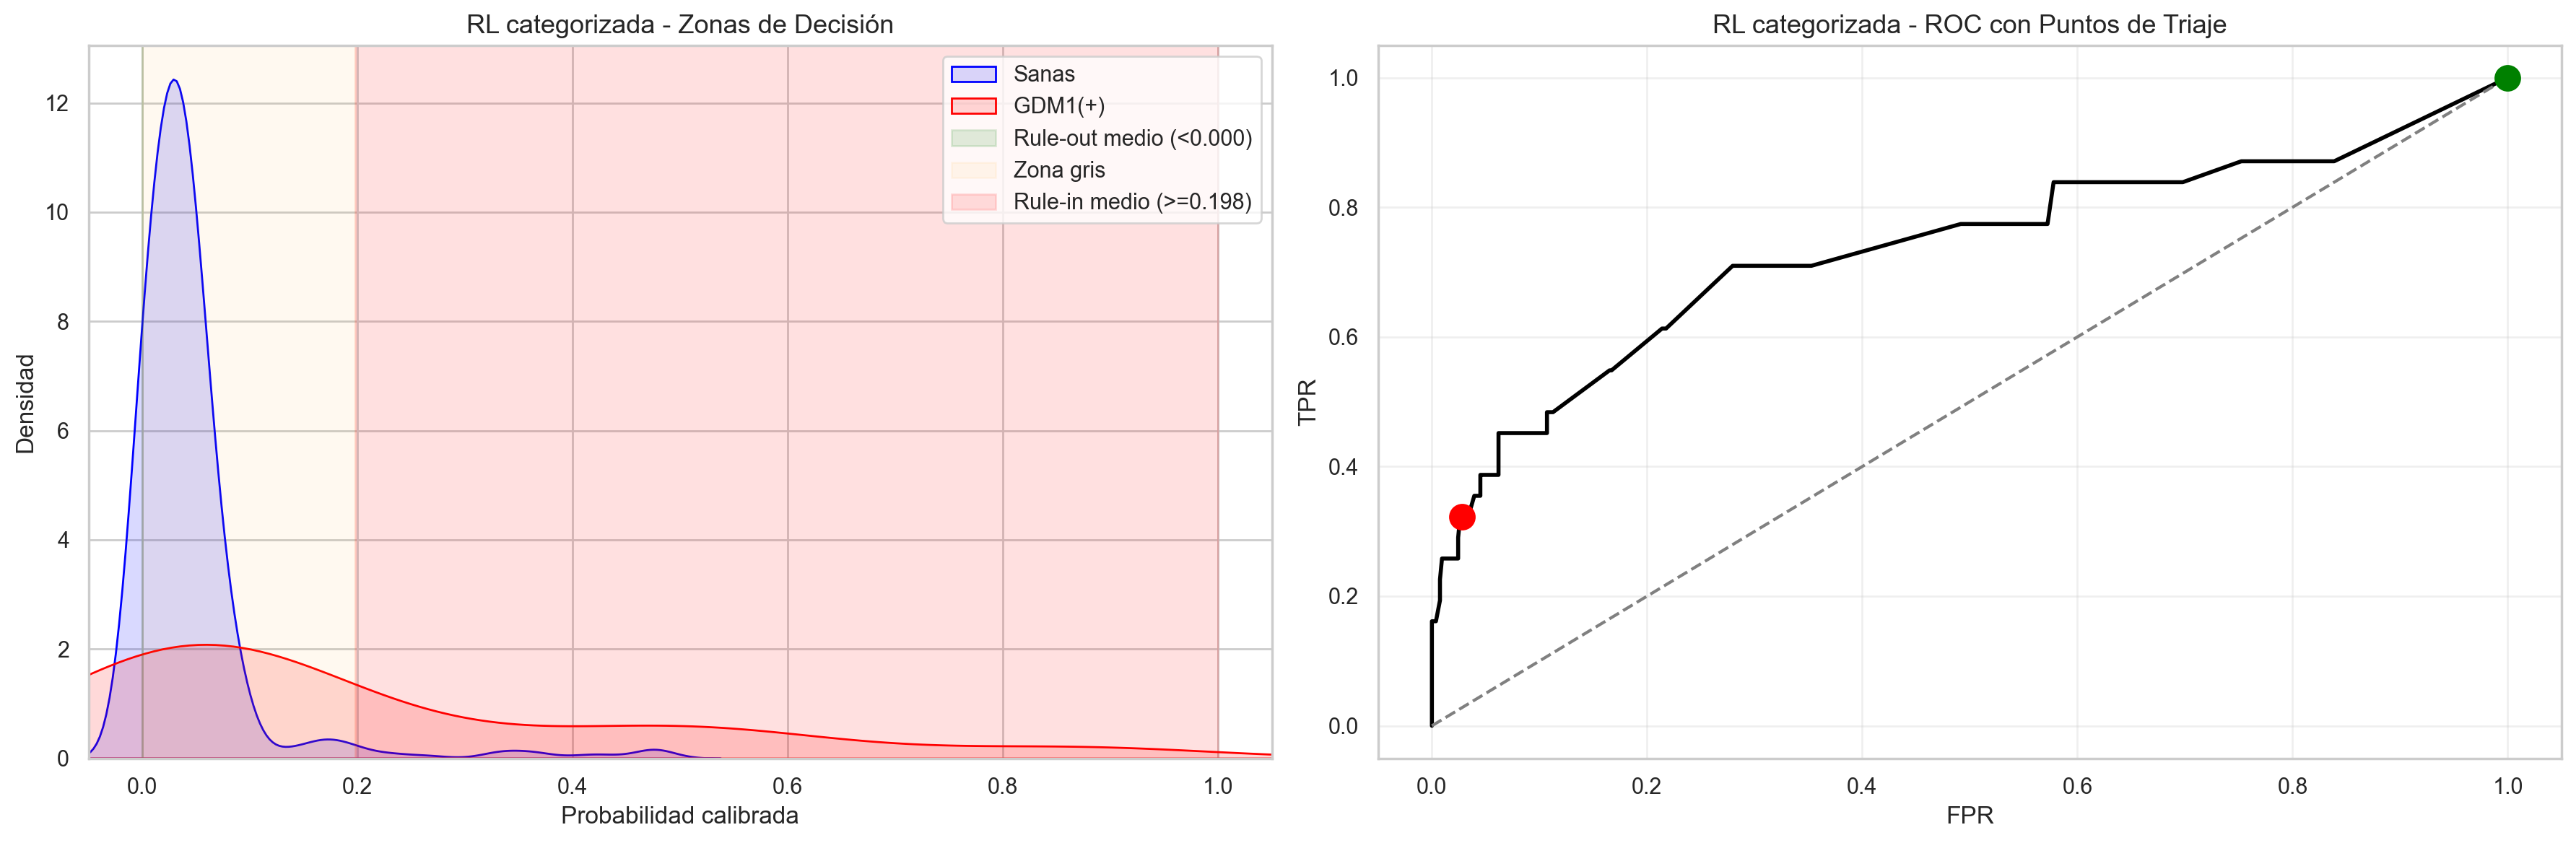


ANÁLISIS IMPACTO CLÍNICO - RL CATEGORIZADA
Población total Test: 564 | Positivos Reales (GDM1=1): 31 (5.5%)
Umbral de descarte (thr_out): 0.0000
Umbral de confirmación (thr_in): 0.1977
-------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL      | GDM1(+)    | % CLASE    | DESCRIPCIÓN
-------------------------------------------------------------------------------------
RULE-OUT (Descarte)       |    0 ( 0.0%) |    0 pts. |   0.0% | Falla en 0 casos (100.0% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    |  539 (95.6%) |   21 pts. |   3.9% | Absorbe al 67.7% de las enfermas
RULE-IN (Confirmación)    |   25 ( 4.4%) |   10 pts. |  40.0% | Precisión Real Consolidada del 40.0%
-------------------------------------------------------------------------------------
VALOR DEL MODELO: Se evita la prueba al 4.4% de la población del test.


In [104]:
# ============================================================
# 5) Triaje final en TEST con plots estilo notebook
# ============================================================
target_sens = 0.90
target_prec = 0.40

fpr_t, tpr_t, thresholds_roc = roc_curve(y_test, y_proba_test)
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba_test)

idx_out_candidates = np.where(tpr_t >= target_sens)[0]
idx_out = idx_out_candidates[0] if len(idx_out_candidates) > 0 else np.argmax(tpr_t)
thr_out = thresholds_roc[idx_out]

idx_in_candidates = np.where(precision >= target_prec)[0]
if len(idx_in_candidates) > 0 and idx_in_candidates[0] < len(thresholds_pr):
    thr_in = thresholds_pr[idx_in_candidates[0]]
else:
    thr_in = np.max(y_proba_test)

if thr_in <= thr_out:
    thr_in = min(0.99, thr_out + 0.05)

def triage(p):
    if p < thr_out:
        return "RULE-OUT (Descarte)"
    elif p >= thr_in:
        return "RULE-IN (Confirmación)"
    else:
        return "ZONA GRIS (Sobrecarga)"

df_triage = pd.DataFrame({
    "Prob": y_proba_test,
    "Real": np.asarray(y_test),
    "Cat": [triage(p) for p in y_proba_test]
})

# ------------------------------------------------------------
# Plots de triaje, estilo GBM/XGB
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_triage[df_triage["Real"] == 0],
    x="Prob",
    fill=True,
    ax=ax1,
    label="Sanas",
    color="blue",
    alpha=0.15,
    cut=3
)
sns.kdeplot(
    data=df_triage[df_triage["Real"] == 1],
    x="Prob",
    fill=True,
    ax=ax1,
    label="GDM1(+) ",
    color="red",
    alpha=0.15,
    cut=3
)

ax1.axvspan(0, thr_out, color="green", alpha=0.12, label=f"Rule-out medio (<{thr_out:.3f})")
ax1.axvspan(thr_out, thr_in, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(thr_in, 1, color="red", alpha=0.12, label=f"Rule-in medio (>={thr_in:.3f})")
ax1.set_title("RL categorizada - Zonas de Decisión", fontsize=13)
ax1.set_xlabel("Probabilidad calibrada")
ax1.set_ylabel("Densidad")
ax1.set_xlim(-0.05, 1.05)
ax1.legend()

ax2.plot(fpr_t, tpr_t, color="black", lw=2)
ax2.scatter(fpr_t[idx_out], tpr_t[idx_out], color="green", s=150, zorder=5)
idx_roc_in = np.argmin(np.abs(thresholds_roc - thr_in))
ax2.scatter(fpr_t[idx_roc_in], tpr_t[idx_roc_in], color="red", s=150, zorder=5)
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.set_title("RL categorizada - ROC con Puntos de Triaje", fontsize=13)
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Reporte numérico
# ------------------------------------------------------------
print("\n" + "=" * 85)
print("ANÁLISIS IMPACTO CLÍNICO - RL CATEGORIZADA")
print("=" * 85)

total_test = len(y_test)
positivos_totales = int(np.sum(y_test))
print(f"Población total Test: {total_test} | Positivos Reales (GDM1=1): {positivos_totales} ({positivos_totales/total_test:.1%})")
print(f"Umbral de descarte (thr_out): {thr_out:.4f}")
print(f"Umbral de confirmación (thr_in): {thr_in:.4f}")
print("-" * 85)
print(f"{'CATEGORÍA':25s} | {'TOTAL':10s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN'}")
print("-" * 85)

orden_cat = ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]
for cat in orden_cat:
    sub = df_triage[df_triage["Cat"] == cat]
    count = len(sub)
    positives = int(sub["Real"].sum())
    perc_total = (count / total_test) * 100 if total_test > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_real = (1 - positives / positivos_totales) * 100 if positivos_totales > 0 else 0
        desc = f"Falla en {positives} casos ({sens_real:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / positivos_totales):.1%} de las enfermas" if positivos_totales > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {positives:4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 85)
ahorro = ((total_test - len(df_triage[df_triage["Cat"] == "ZONA GRIS (Sobrecarga)"])) / total_test) * 100
print(f"VALOR DEL MODELO: Se evita la prueba al {ahorro:.1f}% de la población del test.")
print("=" * 85)

Ejecutando 50 iteraciones de CV para triaje...


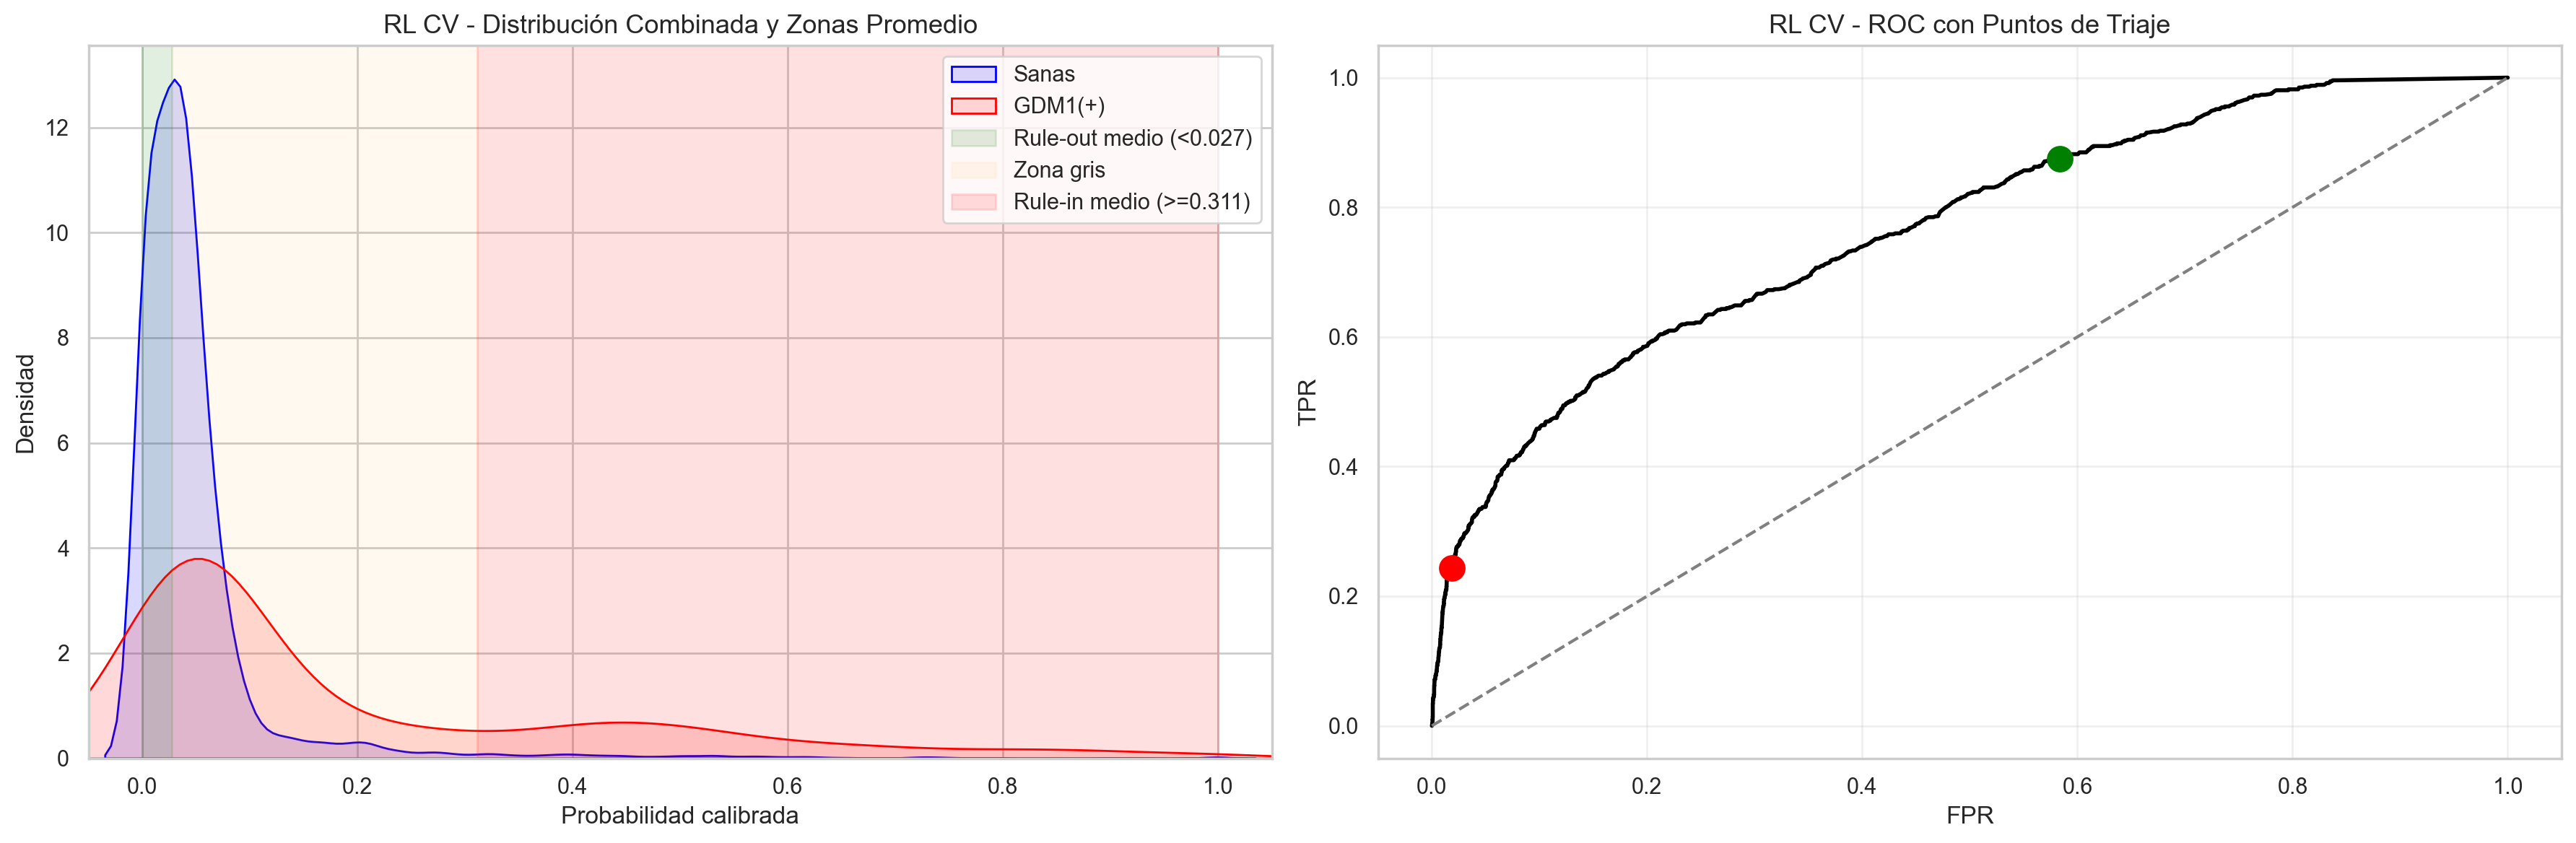


TRIAJE CV - RL CATEGORIZADA
Thr_out medio: 0.0272 ± 0.0128
Thr_in medio : 0.3115 ± 0.1403
Se evita la prueba al 41.2% ± 13.4% de la población analizada.
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 4924 (37.5%) |   38 pts. |   0.8% | Falla en 38 casos (94.7% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 7725 (58.8%) |  472 pts. |   6.1% | Absorbe al 65.6% de las enfermas
RULE-IN (Confirmación)    |  491 ( 3.7%) |  210 pts. |  42.8% | Precisión Real Consolidada del 42.8%
------------------------------------------------------------------------------------------
VALOR DEL MODELO: Se evita la prueba al 41.2% ± 13.4% de la población analizada.


In [105]:
# ============================================================
# 6) Triaje CV con plots estilo notebook
# ============================================================
cv_triaje = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

ahorros_folds = []
umbrales_out = []
umbrales_in = []
probas_normalizadas_grafico = []
reales_acumulados_grafico = []

counts_globales = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {5*10} iteraciones de CV para triaje...")

for fold, (train_idx, val_idx) in enumerate(cv_triaje.split(X_train_cat, y_train), start=1):
    X_tr_fold = X_train_cat.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
    X_val_fold = X_train_cat.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

    calibrated_fold = CalibratedClassifierCV(
        estimator=clone(best_rl),
        method="isotonic",
        cv=3
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        calibrated_fold.fit(X_tr_fold, y_tr_fold)

    y_proba_val = calibrated_fold.predict_proba(X_val_fold)[:, 1]
    y_pred_val = calibrated_fold.predict(X_val_fold)

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_fold, y_proba_val)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else 0.05

    precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_fold, y_proba_val)
    idx_in = np.where(precision_f >= target_prec)[0]
    if len(idx_in) > 0 and idx_in[0] < len(thresholds_pr_f):
        thr_in_f = thresholds_pr_f[idx_in[0]]
    else:
        thr_in_f = np.max(y_proba_val)

    if thr_in_f <= thr_out_f:
        thr_in_f = min(0.99, thr_out_f + 0.05)

    def triage_f(p):
        if p < thr_out_f:
            return "RULE-OUT (Descarte)"
        elif p >= thr_in_f:
            return "RULE-IN (Confirmación)"
        else:
            return "ZONA GRIS (Sobrecarga)"

    cats = np.array([triage_f(p) for p in y_proba_val])
    df_fold = pd.DataFrame({
        "Prob": y_proba_val,
        "Real": np.asarray(y_val_fold),
        "Cat": cats
    })

    gray_rate = (df_fold["Cat"] == "ZONA GRIS (Sobrecarga)").mean() * 100
    ahorro_fold = 100 - gray_rate

    ahorros_folds.append(ahorro_fold)
    umbrales_out.append(thr_out_f)
    umbrales_in.append(thr_in_f)

    probas_normalizadas_grafico.extend(y_proba_val.tolist())
    reales_acumulados_grafico.extend(np.asarray(y_val_fold).tolist())

    for cat in counts_globales.keys():
        sub = df_fold[df_fold["Cat"] == cat]
        counts_globales[cat] += len(sub)
        positives_globales[cat] += int(sub["Real"].sum())

df_grafico_global = pd.DataFrame({
    "Prob": probas_normalizadas_grafico,
    "Real": reales_acumulados_grafico
})

mean_thr_out = float(np.mean(umbrales_out))
mean_thr_in = float(np.mean(umbrales_in))

# ------------------------------------------------------------
# Plots de triaje CV, iguales al estilo del notebook
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global[df_grafico_global["Real"] == 0],
    x="Prob",
    fill=True,
    ax=ax1,
    label="Sanas",
    color="blue",
    alpha=0.15,
    cut=3
)
sns.kdeplot(
    data=df_grafico_global[df_grafico_global["Real"] == 1],
    x="Prob",
    fill=True,
    ax=ax1,
    label="GDM1(+) ",
    color="red",
    alpha=0.15,
    cut=3
)

ax1.axvspan(0, mean_thr_out, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out:.3f})")
ax1.axvspan(mean_thr_out, mean_thr_in, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in, 1, color="red", alpha=0.12, label=f"Rule-in medio (>={mean_thr_in:.3f})")
ax1.set_title("RL CV - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad calibrada")
ax1.set_ylabel("Densidad")
ax1.set_xlim(-0.05, 1.05)
ax1.legend()

fpr_global, tpr_global, _ = roc_curve(df_grafico_global["Real"], df_grafico_global["Prob"])
ax2.plot(fpr_global, tpr_global, color="black", lw=2)
idx_out_global = np.argmin(np.abs(_ - mean_thr_out))
idx_in_global = np.argmin(np.abs(_ - mean_thr_in))
ax2.scatter(fpr_global[idx_out_global], tpr_global[idx_out_global], color="green", s=150, zorder=5)
ax2.scatter(fpr_global[idx_in_global], tpr_global[idx_in_global], color="red", s=150, zorder=5)
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.set_title("RL CV - ROC con Puntos de Triaje", fontsize=13)
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Resumen numérico
# ------------------------------------------------------------
print("\n" + "=" * 90)
print("TRIAJE CV - RL CATEGORIZADA")
print("=" * 90)
print(f"Thr_out medio: {mean_thr_out:.4f} ± {np.std(umbrales_out):.4f}")
print(f"Thr_in medio : {mean_thr_in:.4f} ± {np.std(umbrales_in):.4f}")
print(f"Se evita la prueba al {np.mean(ahorros_folds):.1f}% ± {np.std(ahorros_folds):.1f}% de la población analizada.")
print("=" * 90)

print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

total_pacientes_evaluados = sum(counts_globales.values())
total_positivos_evaluados = sum(positives_globales.values())

for cat in ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]:
    count = counts_globales[cat]
    positives = positives_globales[cat]
    perc_total = (count / total_pacientes_evaluados) * 100 if total_pacientes_evaluados > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_real = (1 - positives / total_positivos_evaluados) * 100 if total_positivos_evaluados > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_real:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados):.1%} de las enfermas" if total_positivos_evaluados > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds):.1f}% ± {np.std(ahorros_folds):.1f}% de la población analizada.")
print("=" * 90)

### GBM

In [106]:
# ============================================================
# 3) GridSearchCV sobre GBM
# ============================================================
import warnings
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# columnas categóricas y numéricas del dataset con cortes
cat_cols = [c for c in X_train_cat.columns if str(X_train_cat[c].dtype) in ("object", "category")]
num_cols = [c for c in X_train_cat.columns if c not in cat_cols]

# preprocesado explícito
pre = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), cat_cols),
    ],
    remainder="passthrough"
)

pipe_gbm_full = Pipeline([
    ("prep", pre),
    ("clf", GradientBoostingClassifier(random_state=42))
])

param_grid_gbm = {
    "clf__n_estimators": [100, 200, 300],
    "clf__learning_rate": [0.01, 0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__max_depth": [2, 3, 5],
    "clf__min_samples_leaf": [1, 3, 5],
    "clf__max_features": [None, "sqrt", "log2"]
}

grid_gbm_full = GridSearchCV(
    estimator=pipe_gbm_full,
    param_grid=param_grid_gbm,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1"},
    refit="roc_auc",
    n_jobs=-1,
    verbose=1
)

print("Ejecutando GridSearchCV sobre GBM (GradientBoostingClassifier)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    grid_gbm_full.fit(X_train_cat, y_train)

print(f"\nMejor ROC-AUC (CV): {grid_gbm_full.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_gbm_full.best_params_}")

df_grid_gbm = pd.DataFrame(grid_gbm_full.cv_results_)
cols_show = [
    "params",
    "mean_test_roc_auc", "std_test_roc_auc",
    "mean_test_pr_auc", "std_test_pr_auc",
    "mean_test_f1", "std_test_f1",
    "rank_test_roc_auc"
]
cols_show = [c for c in cols_show if c in df_grid_gbm.columns]

print("\nTop 10 candidatos (ordenados por ROC-AUC):")
display(df_grid_gbm[cols_show].sort_values("mean_test_roc_auc", ascending=False).head(10).round(4))

best_model_gbm = grid_gbm_full.best_estimator_

Ejecutando GridSearchCV sobre GBM (GradientBoostingClassifier)...
Fitting 5 folds for each of 486 candidates, totalling 2430 fits

Mejor ROC-AUC (CV): 0.7894
Mejores hiperparámetros: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300, 'clf__subsample': 0.8}

Top 10 candidatos (ordenados por ROC-AUC):


,params,mean_test_roc_auc,std_test_roc_auc,mean_test_pr_auc,std_test_pr_auc,mean_test_f1,std_test_f1,rank_test_roc_auc
106,"{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300, 'clf__subsample': 0.8}",0.7894,0.0599,0.3185,0.0865,0.1824,0.0803,1
258,"{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 100, 'clf__subsample': 0.8}",0.7884,0.0712,0.3043,0.0852,0.1951,0.0677,2
139,"{'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100, 'clf__subsample': 1.0}",0.7883,0.0588,0.2970,0.0820,0.0250,0.0500,3
104,"{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200, 'clf__subsample': 0.8}",0.7879,0.0601,0.3251,0.0775,0.1626,0.1135,4
98,"{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200, 'clf__subsample': 0.8}",0.7876,0.0599,0.3240,0.0709,0.1639,0.1129,5
89,"{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 300, 'clf__subsample': 1.0}",0.7876,0.0641,0.3134,0.0852,0.1845,0.0873,6
264,"{'clf__learning_rate': 0.05, 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8}",0.7876,0.0740,0.3130,0.0955,0.1782,0.0835,7
100,"{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_features': 'log2', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300, 'clf__subsample': 0.8}",0.7872,0.0607,0.3136,0.0809,0.2032,0.0742,8
138,"{'clf__learning_rate': 0.01, 'clf__max_depth': 5, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100, 'clf__subsample': 0.8}",0.7869,0.0630,0.3072,0.0830,0.0000,0.0000,9
83,"{'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300, 'clf__subsample': 1.0}",0.7863,0.0676,0.3119,0.0876,0.2044,0.0793,10



RESULTADOS EN TEST - GBM
ROC-AUC: 0.7326
PR-AUC : 0.3651
F1     : 0.3243


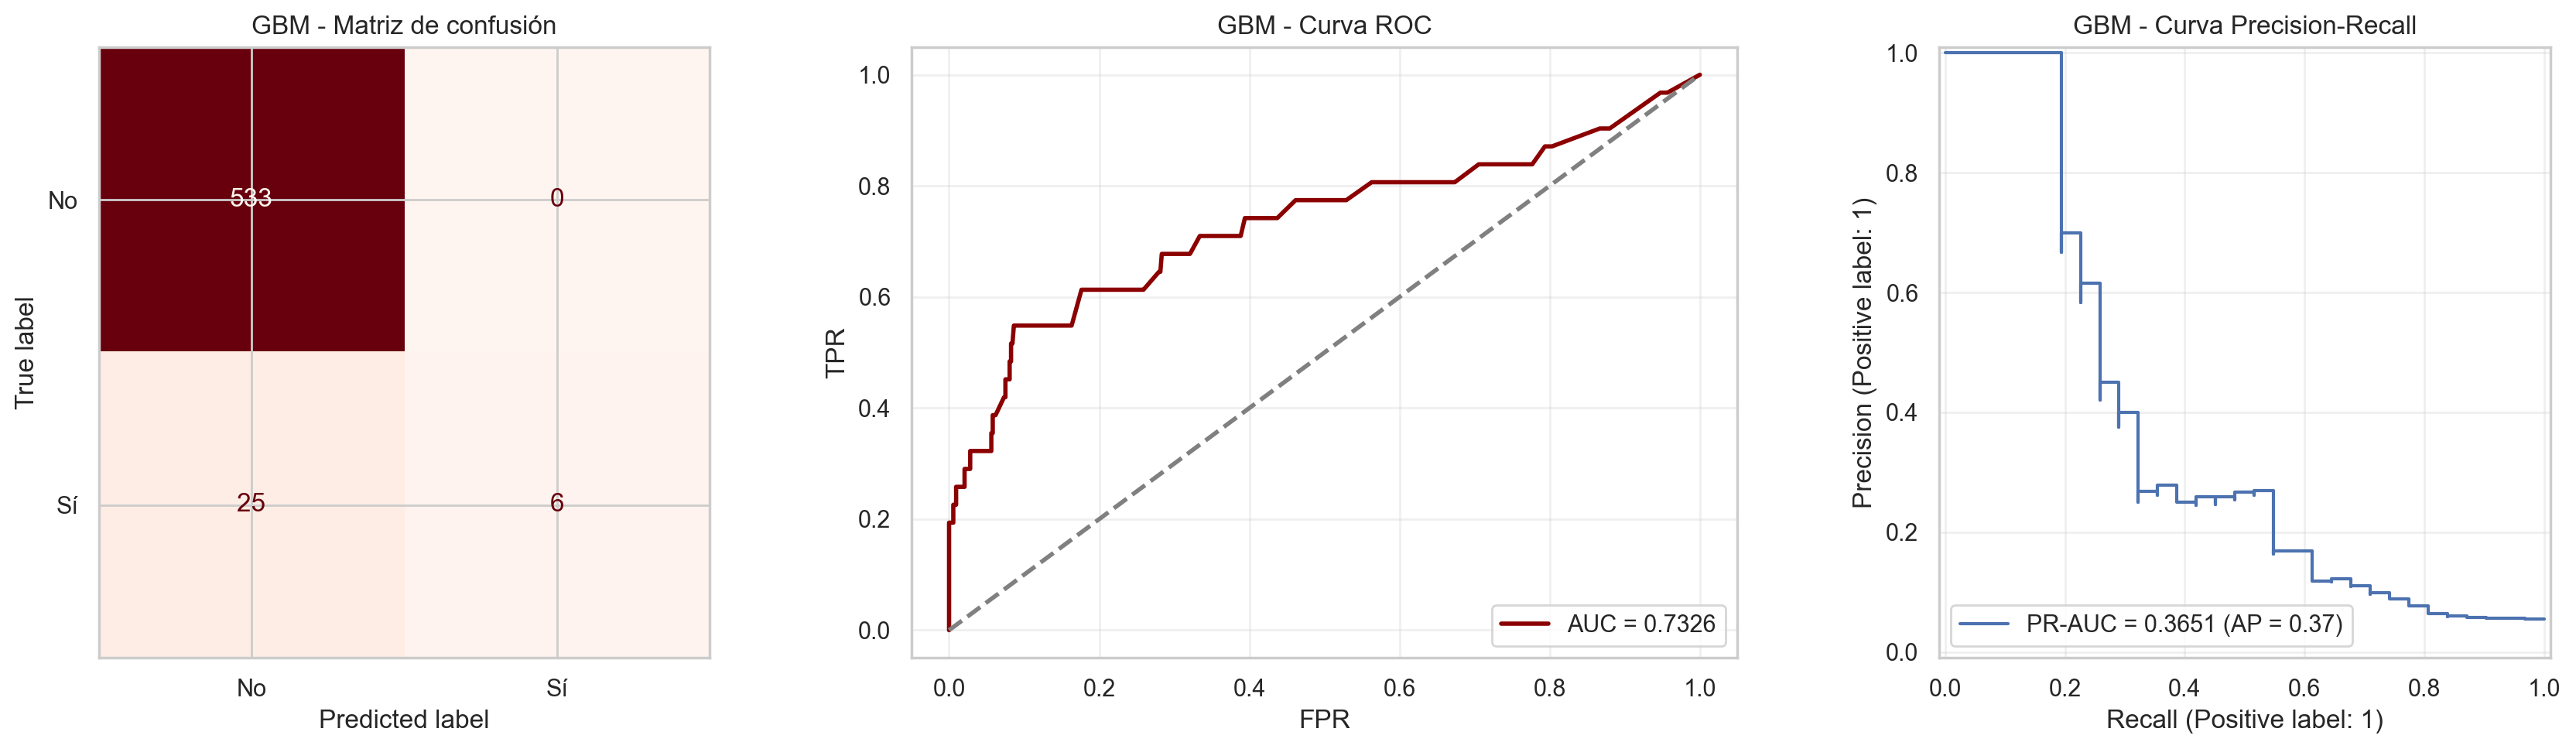

In [107]:
# ============================================================
# 4) Evaluación en TEST - GBM
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, PrecisionRecallDisplay
)

calibrated_gbm = CalibratedClassifierCV(estimator=best_model_gbm, method="isotonic", cv=5)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    calibrated_gbm.fit(X_train_cat, y_train)

y_pred_test_gbm = calibrated_gbm.predict(X_test_cat)
y_proba_test_gbm = calibrated_gbm.predict_proba(X_test_cat)[:, 1]

auc_test_gbm = roc_auc_score(y_test, y_proba_test_gbm)
pr_auc_test_gbm = average_precision_score(y_test, y_proba_test_gbm)
f1_test_gbm = f1_score(y_test, y_pred_test_gbm)

print("\n" + "=" * 85)
print("RESULTADOS EN TEST - GBM")
print("=" * 85)
print(f"ROC-AUC: {auc_test_gbm:.4f}")
print(f"PR-AUC : {pr_auc_test_gbm:.4f}")
print(f"F1     : {f1_test_gbm:.4f}")
print("=" * 85)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test, y_pred_test_gbm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Sí"])
disp.plot(ax=axes[0], cmap="Reds", colorbar=False, values_format="d")
axes[0].set_title("GBM - Matriz de confusión")

fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test_gbm)
axes[1].plot(fpr_test, tpr_test, color="darkred", lw=2, label=f"AUC = {auc_test_gbm:.4f}")
axes[1].plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--")
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].set_title("GBM - Curva ROC")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_test_gbm,
    ax=axes[2],
    name=f"PR-AUC = {pr_auc_test_gbm:.4f}"
)
axes[2].set_title("GBM - Curva Precision-Recall")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Ejecutando 50 iteraciones de CV para triaje...


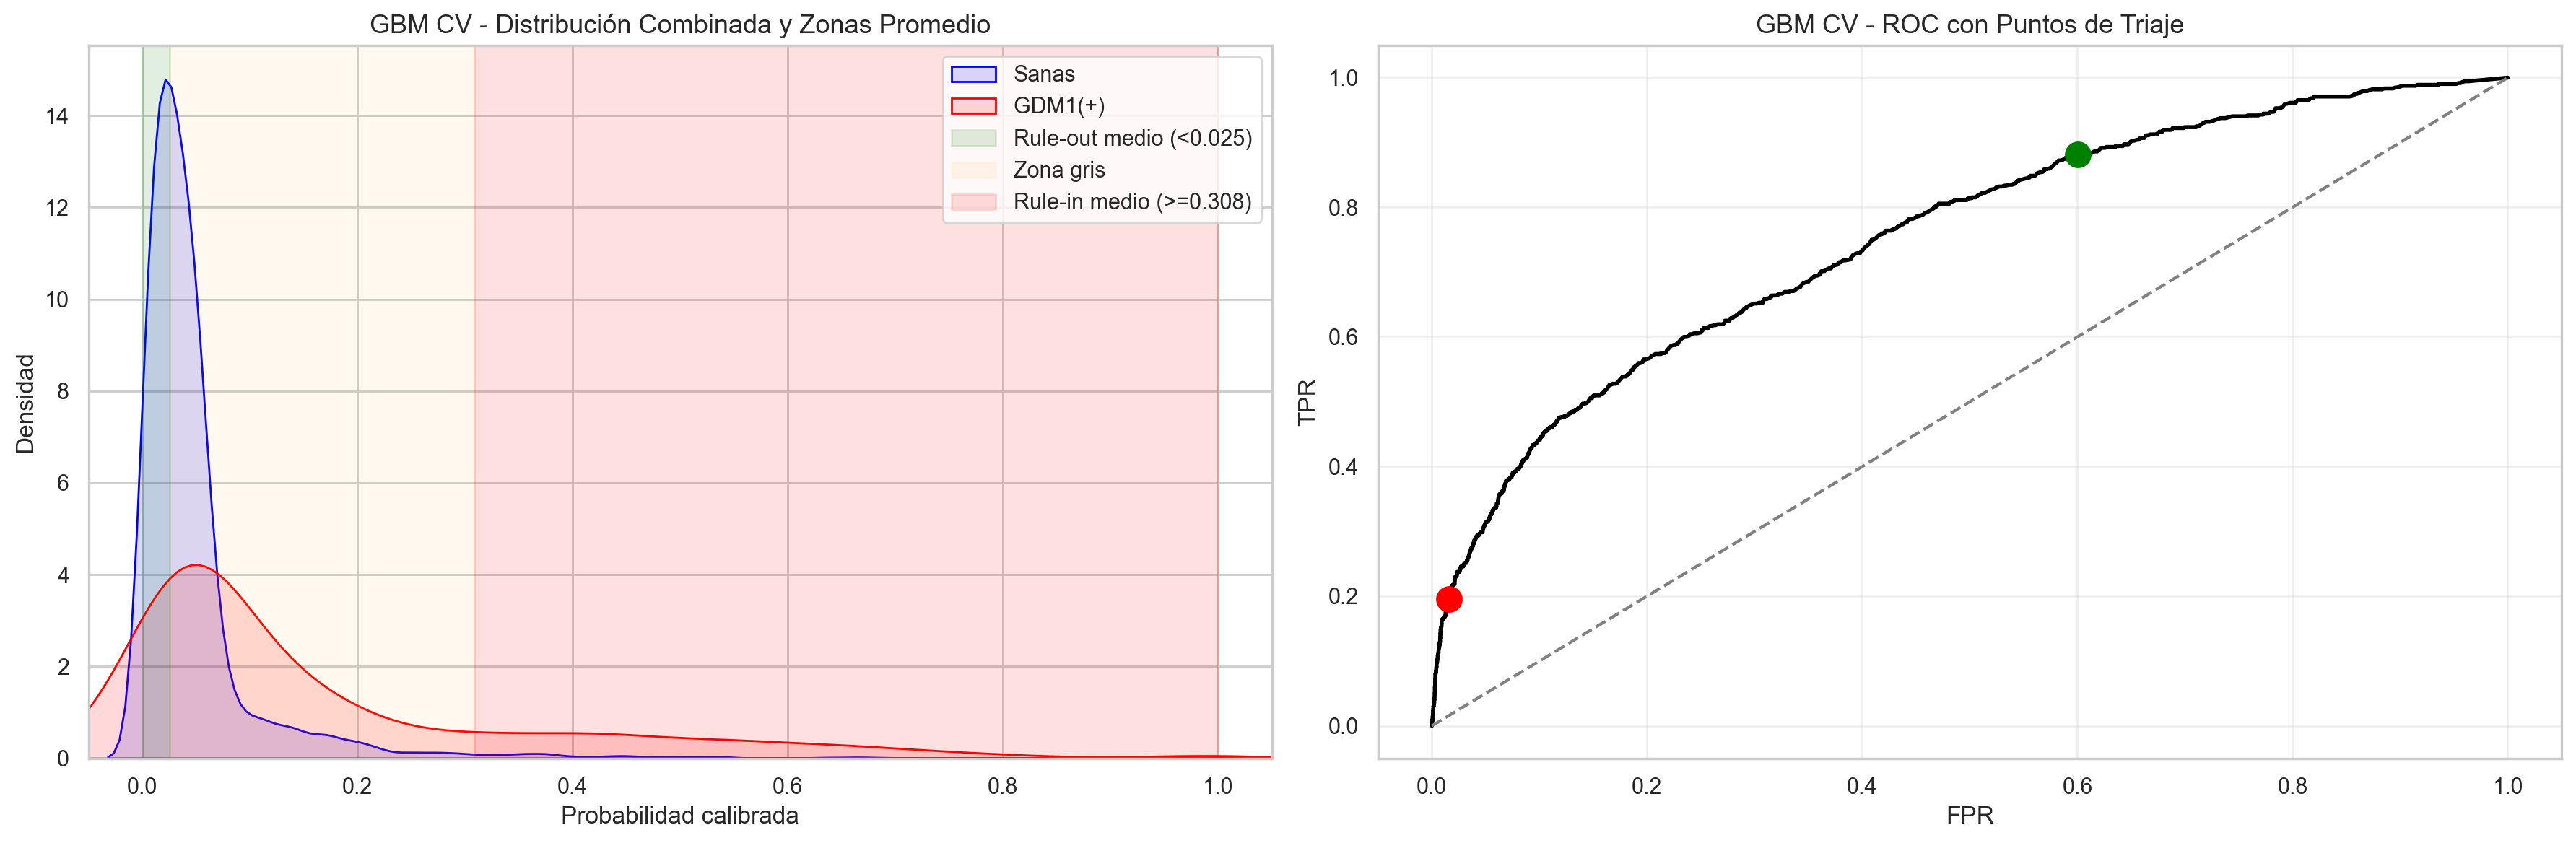


TRIAJE CV - GBM CATEGORIZADA
Thr_out medio: 0.0251 ± 0.0105
Thr_in medio : 0.3083 ± 0.1384
Se evita la prueba al 36.6% ± 13.3% de la población analizada.
------------------------------------------------------------------------------------------
CATEGORÍA                 | TOTAL        | GDM1(+)    | % CLASE    | DESCRIPCIÓN CLÍNICA
------------------------------------------------------------------------------------------
RULE-OUT (Descarte)       | 4364 (33.2%) |   32 pts. |   0.7% | Falla en 32 casos (95.6% Sensibilidad Real)
ZONA GRIS (Sobrecarga)    | 8332 (63.4%) |  501 pts. |   6.0% | Absorbe al 69.6% de las enfermas
RULE-IN (Confirmación)    |  444 ( 3.4%) |  187 pts. |  42.1% | Precisión Real Consolidada del 42.1%
------------------------------------------------------------------------------------------
VALOR DEL MODELO: Se evita la prueba al 36.6% ± 13.3% de la población analizada.


In [108]:
# ============================================================
# 5) Triaje CV con plots estilo notebook (GBM)
# ============================================================
cv_triaje = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

ahorros_folds = []
umbrales_out = []
umbrales_in = []
probas_normalizadas_grafico = []
reales_acumulados_grafico = []

counts_globales = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}
positives_globales = {
    "RULE-OUT (Descarte)": 0,
    "ZONA GRIS (Sobrecarga)": 0,
    "RULE-IN (Confirmación)": 0
}

print(f"Ejecutando {5*10} iteraciones de CV para triaje...")

for fold, (train_idx, val_idx) in enumerate(cv_triaje.split(X_train_cat, y_train), start=1):
    X_tr_fold = X_train_cat.iloc[train_idx]
    y_tr_fold = y_train.iloc[train_idx] if hasattr(y_train, "iloc") else y_train[train_idx]
    X_val_fold = X_train_cat.iloc[val_idx]
    y_val_fold = y_train.iloc[val_idx] if hasattr(y_train, "iloc") else y_train[val_idx]

    calibrated_fold = CalibratedClassifierCV(
        estimator=clone(best_model_gbm),
        method="isotonic",
        cv=3
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        calibrated_fold.fit(X_tr_fold, y_tr_fold)

    y_proba_val = calibrated_fold.predict_proba(X_val_fold)[:, 1]
    y_pred_val = calibrated_fold.predict(X_val_fold)

    fpr_f, tpr_f, thrs_roc_f = roc_curve(y_val_fold, y_proba_val)
    idx_out = np.where(tpr_f >= target_sens)[0]
    thr_out_f = thrs_roc_f[idx_out[0]] if len(idx_out) > 0 else 0.05

    precision_f, recall_f, thresholds_pr_f = precision_recall_curve(y_val_fold, y_proba_val)
    idx_in = np.where(precision_f >= target_prec)[0]
    if len(idx_in) > 0 and idx_in[0] < len(thresholds_pr_f):
        thr_in_f = thresholds_pr_f[idx_in[0]]
    else:
        thr_in_f = np.max(y_proba_val)

    if thr_in_f <= thr_out_f:
        thr_in_f = min(0.99, thr_out_f + 0.05)

    def triage_f(p):
        if p < thr_out_f:
            return "RULE-OUT (Descarte)"
        elif p >= thr_in_f:
            return "RULE-IN (Confirmación)"
        else:
            return "ZONA GRIS (Sobrecarga)"

    cats = np.array([triage_f(p) for p in y_proba_val])
    df_fold = pd.DataFrame({
        "Prob": y_proba_val,
        "Real": np.asarray(y_val_fold),
        "Cat": cats
    })

    gray_rate = (df_fold["Cat"] == "ZONA GRIS (Sobrecarga)").mean() * 100
    ahorro_fold = 100 - gray_rate

    ahorros_folds.append(ahorro_fold)
    umbrales_out.append(thr_out_f)
    umbrales_in.append(thr_in_f)

    probas_normalizadas_grafico.extend(y_proba_val.tolist())
    reales_acumulados_grafico.extend(np.asarray(y_val_fold).tolist())

    for cat in counts_globales.keys():
        sub = df_fold[df_fold["Cat"] == cat]
        counts_globales[cat] += len(sub)
        positives_globales[cat] += int(sub["Real"].sum())

df_grafico_global = pd.DataFrame({
    "Prob": probas_normalizadas_grafico,
    "Real": reales_acumulados_grafico
})

mean_thr_out = float(np.mean(umbrales_out))
mean_thr_in = float(np.mean(umbrales_in))

# ------------------------------------------------------------
# Plots de triaje CV, iguales al estilo del notebook
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.kdeplot(
    data=df_grafico_global[df_grafico_global["Real"] == 0],
    x="Prob",
    fill=True,
    ax=ax1,
    label="Sanas",
    color="blue",
    alpha=0.15,
    cut=3
)
sns.kdeplot(
    data=df_grafico_global[df_grafico_global["Real"] == 1],
    x="Prob",
    fill=True,
    ax=ax1,
    label="GDM1(+) ",
    color="red",
    alpha=0.15,
    cut=3
)

ax1.axvspan(0, mean_thr_out, color="green", alpha=0.12, label=f"Rule-out medio (<{mean_thr_out:.3f})")
ax1.axvspan(mean_thr_out, mean_thr_in, color="orange", alpha=0.06, label="Zona gris")
ax1.axvspan(mean_thr_in, 1, color="red", alpha=0.12, label=f"Rule-in medio (>={mean_thr_in:.3f})")
ax1.set_title("GBM CV - Distribución Combinada y Zonas Promedio", fontsize=13)
ax1.set_xlabel("Probabilidad calibrada")
ax1.set_ylabel("Densidad")
ax1.set_xlim(-0.05, 1.05)
ax1.legend()

fpr_global, tpr_global, _ = roc_curve(df_grafico_global["Real"], df_grafico_global["Prob"])
ax2.plot(fpr_global, tpr_global, color="black", lw=2)
idx_out_global = np.argmin(np.abs(_ - mean_thr_out))
idx_in_global = np.argmin(np.abs(_ - mean_thr_in))
ax2.scatter(fpr_global[idx_out_global], tpr_global[idx_out_global], color="green", s=150, zorder=5)
ax2.scatter(fpr_global[idx_in_global], tpr_global[idx_in_global], color="red", s=150, zorder=5)
ax2.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--")
ax2.set_title("GBM CV - ROC con Puntos de Triaje", fontsize=13)
ax2.set_xlabel("FPR")
ax2.set_ylabel("TPR")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Resumen numérico
# ------------------------------------------------------------
print("\n" + "=" * 90)
print("TRIAJE CV - GBM CATEGORIZADA")
print("=" * 90)
print(f"Thr_out medio: {mean_thr_out:.4f} ± {np.std(umbrales_out):.4f}")
print(f"Thr_in medio : {mean_thr_in:.4f} ± {np.std(umbrales_in):.4f}")
print(f"Se evita la prueba al {np.mean(ahorros_folds):.1f}% ± {np.std(ahorros_folds):.1f}% de la población analizada.")
print("=" * 90)

print("-" * 90)
print(f"{'CATEGORÍA':25s} | {'TOTAL':12s} | {'GDM1(+)':10s} | {'% CLASE':10s} | {'DESCRIPCIÓN CLÍNICA'}")
print("-" * 90)

total_pacientes_evaluados = sum(counts_globales.values())
total_positivos_evaluados = sum(positives_globales.values())

for cat in ["RULE-OUT (Descarte)", "ZONA GRIS (Sobrecarga)", "RULE-IN (Confirmación)"]:
    count = counts_globales[cat]
    positives = positives_globales[cat]
    perc_total = (count / total_pacientes_evaluados) * 100 if total_pacientes_evaluados > 0 else 0
    perc_pos = (positives / count * 100) if count > 0 else 0

    if "OUT" in cat:
        sens_real = (1 - positives / total_positivos_evaluados) * 100 if total_positivos_evaluados > 0 else 0
        desc = f"Falla en {int(positives)} casos ({sens_real:.1f}% Sensibilidad Real)"
    elif "IN" in cat:
        desc = f"Precisión Real Consolidada del {perc_pos:.1f}%"
    else:
        desc = f"Absorbe al {(positives / total_positivos_evaluados):.1%} de las enfermas" if total_positivos_evaluados > 0 else "Sin positivos"

    print(f"{cat:25s} | {count:4d} ({perc_total:4.1f}%) | {int(positives):4d} pts. | {perc_pos:5.1f}% | {desc}")

print("-" * 90)
print(f"VALOR DEL MODELO: Se evita la prueba al {np.mean(ahorros_folds):.1f}% ± {np.std(ahorros_folds):.1f}% de la población analizada.")
print("=" * 90)